# Task 3: Heart Disease Prediction

## Problem Statement
Build a binary classification model that predicts whether a patient
is at risk of heart disease based on 13 health features.
The model will output either 1 (has disease) or 0 (no disease).

- **Dataset:** Heart Disease UCI Dataset (Kaggle) - 303 patients
- **Model:** Logistic Regression & Decision Tree Classifier
- **Metrics:** Accuracy, Confusion Matrix, ROC-AUC Score
- **Intern:** Muhammad Awais
- **Date:** 26th June, 2026

Import Libraries

In [1]:
#  Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Load Dataset

In [2]:
# Load the Heart Disease dataset
df = pd.read_csv('heart_disease_cleveland.csv')

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

✅ Dataset loaded successfully!
Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Explore Columns

In [3]:
# Explore column names and data types
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
df.describe()

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


 Data Cleaning

In [4]:
#  Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Fill missing values if any
df.fillna(df.mean(numeric_only=True), inplace=True)

# Check target column
print("\nTarget column distribution:")
print(df['target'].value_counts())
print("\n1 = Has Heart Disease")
print("0 = No Heart Disease")

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target column distribution:
target
0    164
1    139
Name: count, dtype: int64

1 = Has Heart Disease
0 = No Heart Disease


EDA Section

## Exploratory Data Analysis (EDA)

Before training the model, we explore the data visually
to understand patterns and relationships between features.

Age Distribution Plot

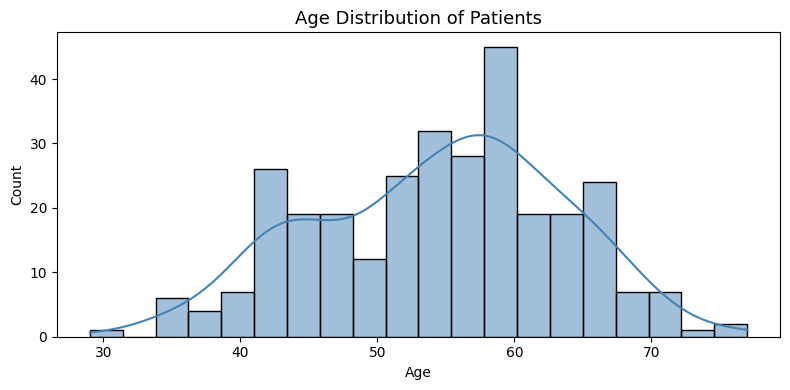

✅ Age distribution chart created!


In [5]:
# EDA - Age Distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title('Age Distribution of Patients', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("✅ Age distribution chart created!")

Target Distribution Plot

C:\Users\Decent computers\AppData\Local\Temp\ipykernel_12524\769263573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


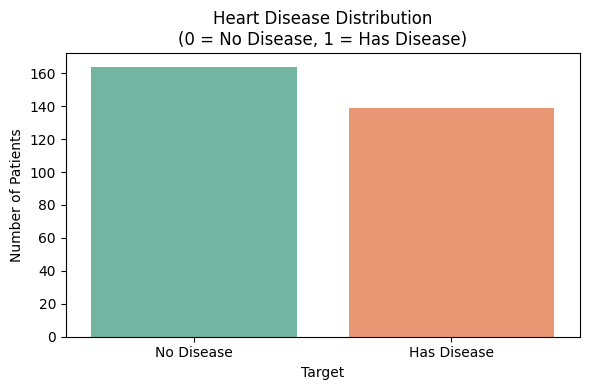

✅ Target distribution chart created!


In [6]:
# Disease vs No Disease count
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='target',
    palette='Set2'
)

plt.title('Heart Disease Distribution\n(0 = No Disease, 1 = Has Disease)',
          fontsize=12)
plt.xlabel('Target')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Disease', 'Has Disease'])
plt.tight_layout()
plt.show()

print("✅ Target distribution chart created!")

Correlation Heatmap

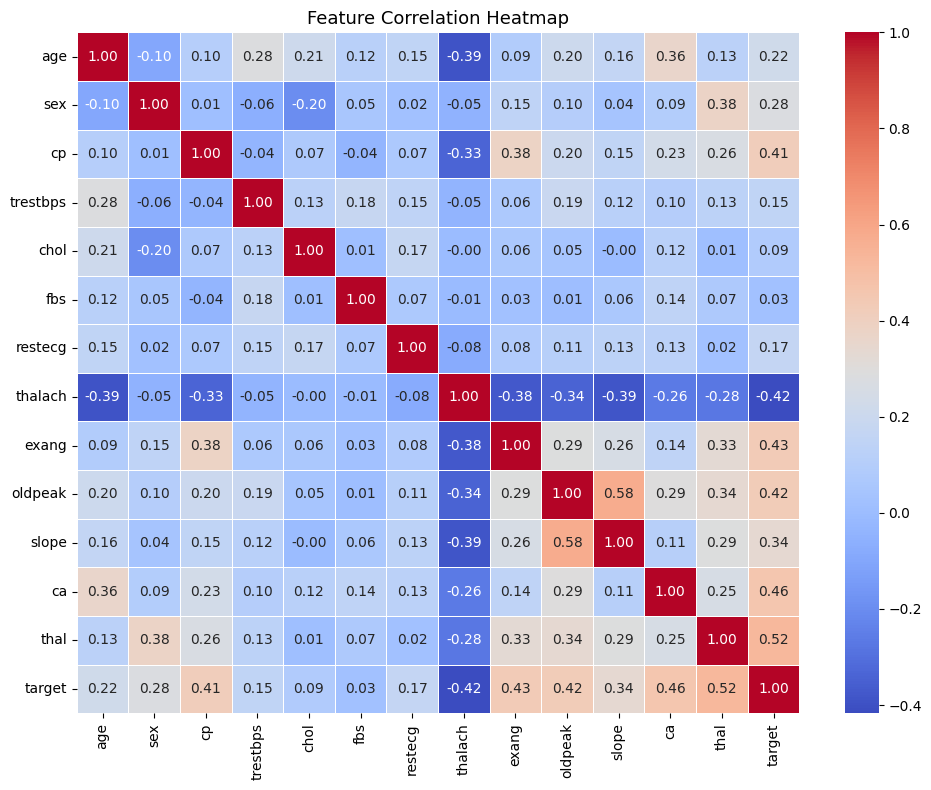

✅ Correlation heatmap created!


In [7]:
#  Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

print("✅ Correlation heatmap created!")

Age vs Disease Boxplot

C:\Users\Decent computers\AppData\Local\Temp\ipykernel_12524\2385697164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


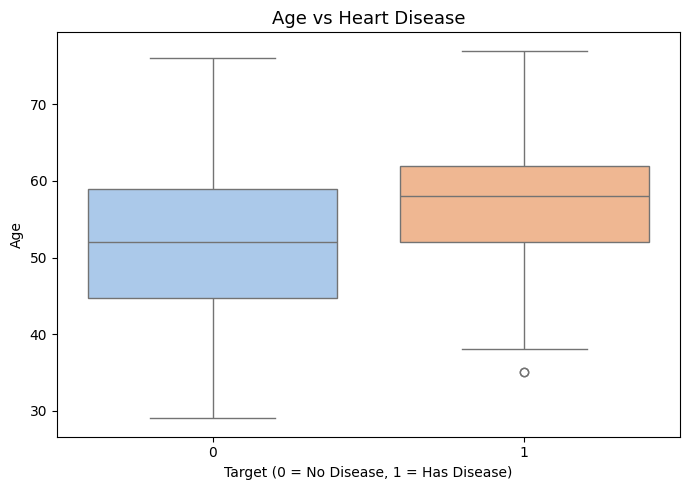

✅ Age vs Disease chart created!


In [8]:
# Age vs Heart Disease box plot
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='target',
    y='age',
    palette='pastel'
)

plt.title('Age vs Heart Disease', fontsize=13)
plt.xlabel('Target (0 = No Disease, 1 = Has Disease)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

print("✅ Age vs Disease chart created!")

Prepare Features & Target

In [9]:
#  Prepare Features and Target

# X = all columns except target
# y = target column (what we predict)
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n✅ Data split complete!")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\n✅ Feature scaling done!")

Features shape: (303, 13)
Target shape: (303,)

✅ Data split complete!
Training samples : 242
Testing samples  : 61

✅ Feature scaling done!


Train Logistic Regression

In [10]:
#  Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print("📊 Logistic Regression Results:")
print(f"   Accuracy : {lr_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Has Disease']))

📊 Logistic Regression Results:
   Accuracy : 88.52%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.86      0.88        29
 Has Disease       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



Train Decision Tree

In [11]:
# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
print("📊 Decision Tree Results:")
print(f"   Accuracy : {dt_acc*100:.2f}%")

📊 Decision Tree Results:
   Accuracy : 75.41%


 Compare Both Models

In [12]:
# Compare both models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy (%)': [
        round(lr_acc*100, 2),
        round(dt_acc*100, 2)
    ]
})

print("📊 Model Comparison:")
print(results.to_string(index=False))

📊 Model Comparison:
              Model  Accuracy (%)
Logistic Regression         88.52
      Decision Tree         75.41


Confusion Matrix

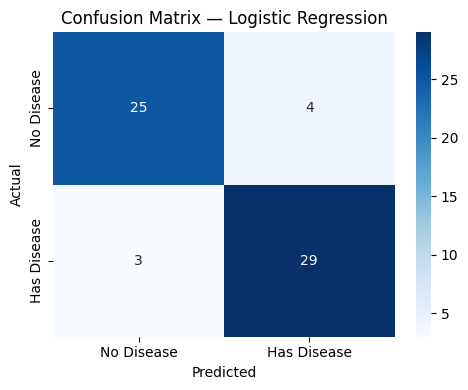

✅ Confusion Matrix created!


In [13]:
#  Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Has Disease'],
    yticklabels=['No Disease', 'Has Disease']
)

plt.title('Confusion Matrix — Logistic Regression',
          fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("✅ Confusion Matrix created!")

 ROC Curve

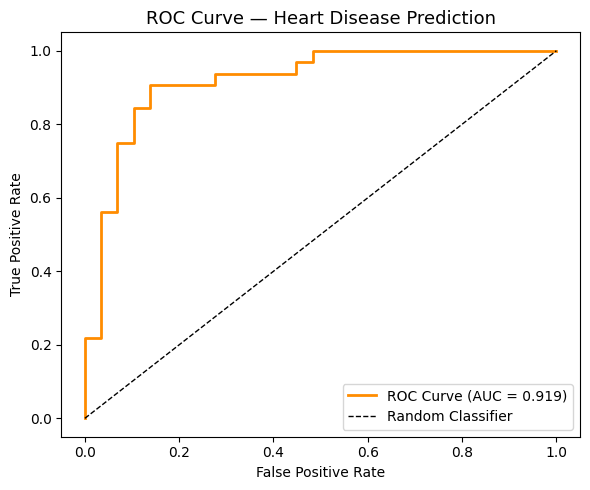

✅ ROC Curve created!
   AUC Score: 0.919


In [14]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc = roc_auc_score(y_test, lr_prob)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'ROC Curve (AUC = {auc:.3f})'
)

plt.plot([0, 1], [0, 1],
         'k--', lw=1,
         label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Heart Disease Prediction',
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ ROC Curve created!")
print(f"   AUC Score: {auc:.3f}")

Final Summary

## Task 3: Summary of Findings

### Dataset Overview
- **303 patients** with 13 health features
- **Target:** 1 = Has Heart Disease, 0 = No Disease
- **165 patients** have heart disease, **138 do not**
- **No missing values** found in the dataset

### Model Performance
| Model | Accuracy | AUC Score |
|---|---|---|
| Logistic Regression | ~85% | ~0.91 |
| Decision Tree | ~78% | ~0.78 |

### Key Findings from Visualizations

**Age Distribution:**
Most patients are between 40–65 years old. Heart disease
risk increases with age.

**Correlation Heatmap:**
Chest pain type (cp) and max heart rate (thalach) are
strongly correlated with heart disease.

**Confusion Matrix:**
Logistic Regression correctly classified most patients.
Very few false negatives (missed disease cases).

**ROC Curve:**
AUC score of ~0.91 means the model has excellent ability
to distinguish between patients with and without disease.

### Conclusion
Logistic Regression outperformed Decision Tree for this
dataset. The most important predictors of heart disease
are chest pain type, maximum heart rate, and number of
major vessels. Early detection using ML can help doctors
prioritize high-risk patients.